In [1]:
import numpy as np
import yfinance as yf
from scipy.stats import norm
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ticker = "SPY"
option_type = "call"
expiry_date = "2027-01-15"

In [3]:
def BlackScholesPrice(S, K, T, r, q, sigma, option_type="call"):
    """
    S - current price of the underlying
    K - strike price
    T - time to maturity, in years
    r - risk-free rate (annualized, continuous)
    q - rendimiento por dividendo
    sigma - volatility (annualized)
    option_type - "call" or "put"
    """

    # Guard against the degenerate T=0 case
    if T <= 0:
        if option_type == "call":
            return max(S - K, 0.0)
        else:
            return max(K - S, 0.0)

    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    if option_type == "call":
        price = S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    elif option_type == "put":
        price = K*np.exp(-r*T)*norm.cdf(-d2) - S*np.exp(-q*T)*norm.cdf(-d1)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    return price

In [4]:
def GetDividendYield(ticker):
    """
    info = yf.Ticker(ticker).info
    q = info.get('dividendYield') or info.get('trailingAnnualDividendYield') or 0.0
    return q/100.0 if q > 1 else q   # yfinance a veces lo da como % (1.2) y a veces como decimal (0.012)
    """
    return 0.012

In [5]:
def ImpliedVol(market_price, S, K, T, r, q, option_type='call', tol=1e-6):
    lo, hi = 1e-6, 5.0 # Intervalo de volatidad
    def f(sigma):
        return BlackScholesPrice(S, K, T, r, q, sigma, option_type) - market_price

    # Comprobamos si hay raíz en el intervalo
    if f(lo) * f(hi) > 0:
        return np.nan      # sin cambio de signo -> no hay raíz -> retorna NaN

    while hi - lo > tol:
        midpoint = (lo + hi) / 2
        if f(midpoint) * f(lo) >= 0:
            lo = midpoint
        else:
            hi = midpoint
    return (lo + hi) / 2

In [6]:
def FetchOptions(ticker, expiry, option_type='call'):
    tk = yf.Ticker(ticker)
    chain = tk.option_chain(expiry)
    if option_type == 'call':
        return chain.calls
    elif option_type == 'put':
        return chain.puts
    else:
        raise ValueError("option_type must be 'call' or 'put'")

In [7]:
def GetSpot(ticker):
    tk = yf.Ticker(ticker)
    hist = tk.history(period='1d')     # el historial del último día
    return hist['Close'].iloc[-1]      # el último cierre disponible

def GetRiskFreeRate():
    irx = yf.Ticker('^IRX').history(period='5d')
    return irx['Close'].iloc[-1] / 100.0

def TimeToExpiry(expiry):
    today = pd.Timestamp.now().normalize()
    vencimiento = pd.Timestamp(expiry)
    days = (vencimiento - today).days
    return days / 365.0

In [8]:
def CleanChain(options, spot, min_volume=10, min_oi=50, moneyness_band=(0.7, 1.3)):
    df = options.copy()   # trabajamos sobre una copia, no tocamos el original

    # 1. bid/ask válidos
    df = df[(df['bid'] > 0) & (df['ask'] > df['bid'])]

    # 2. liquidez: volumen O interés abierto por encima del umbral
    df = df[(df['volume'].fillna(0) >= min_volume) | (df['openInterest'].fillna(0) >= min_oi)]

    # 3. banda de moneyness alrededor del spot
    df['moneyness'] = df['strike'] / spot
    lo, hi = moneyness_band
    df = df[(df['moneyness'] >= lo) & (df['moneyness'] <= hi)]

    # precio de mercado = mid
    df['mid'] = (df['bid'] + df['ask']) / 2

    return df.reset_index(drop=True)

In [9]:
def AddImpliedVol(df, spot, r, q, T, option_type='call'):
    df = df.copy()
    df['iv'] = df.apply(
        lambda row: ImpliedVol(
            market_price = row['mid'],
            S = spot,
            K = row['strike'],
            T = T,
            r = r,
            q = q,
            option_type = option_type
        ),
        axis=1
    )
    df = df.dropna(subset=['iv'])
    return df

In [16]:
options = FetchOptions(ticker, expiry_date, option_type)

In [17]:
CleanChain(options, GetSpot(ticker))

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,moneyness,mid
0,SPY270115C00525000,2026-07-01 13:46:07+00:00,525.0,231.84,234.13,237.67,0.0,0.0,1.0,757,0.439916,True,REGULAR,USD,0.700750,235.900
1,SPY270115C00530000,2026-06-12 18:08:20+00:00,530.0,224.73,228.85,232.37,0.0,0.0,5.0,235,0.428076,True,REGULAR,USD,0.707424,230.610
2,SPY270115C00535000,2026-06-15 14:42:10+00:00,535.0,231.02,225.12,228.46,0.0,0.0,19.0,178,0.430243,True,REGULAR,USD,0.714098,226.790
3,SPY270115C00540000,2026-06-30 19:52:51+00:00,540.0,220.93,219.55,222.91,0.0,0.0,2.0,184,0.416128,True,REGULAR,USD,0.720772,221.230
4,SPY270115C00545000,2026-06-18 19:57:58+00:00,545.0,219.38,215.67,218.75,0.0,0.0,1.0,90,0.415533,True,REGULAR,USD,0.727445,217.210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,SPY270115C00950000,2026-07-02 19:56:43+00:00,950.0,0.35,0.36,0.38,0.0,0.0,17.0,2476,0.144906,False,REGULAR,USD,1.268024,0.370
86,SPY270115C00955000,2026-06-30 17:25:52+00:00,955.0,0.37,0.31,0.38,0.0,0.0,300.0,535,0.147592,False,REGULAR,USD,1.274698,0.345
87,SPY270115C00960000,2026-07-02 19:12:50+00:00,960.0,0.29,0.29,0.36,0.0,0.0,17.0,6153,0.149300,False,REGULAR,USD,1.281372,0.325
88,SPY270115C00965000,2026-06-26 18:46:55+00:00,965.0,0.23,0.28,0.30,0.0,0.0,67.0,190,0.148446,False,REGULAR,USD,1.288046,0.290


In [18]:
spot = GetSpot(ticker)
r    = GetRiskFreeRate()
q    = GetDividendYield(ticker)
T    = TimeToExpiry(expiry_date)

AddImpliedVol(CleanChain(options, spot), spot, r, q, T, option_type)

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,moneyness,mid,iv
0,SPY270115C00525000,2026-07-01 13:46:07+00:00,525.0,231.84,234.13,237.67,0.0,0.0,1.0,757,0.439916,True,REGULAR,USD,0.700750,235.900,0.367646
1,SPY270115C00530000,2026-06-12 18:08:20+00:00,530.0,224.73,228.85,232.37,0.0,0.0,5.0,235,0.428076,True,REGULAR,USD,0.707424,230.610,0.354463
2,SPY270115C00535000,2026-06-15 14:42:10+00:00,535.0,231.02,225.12,228.46,0.0,0.0,19.0,178,0.430243,True,REGULAR,USD,0.714098,226.790,0.362171
3,SPY270115C00540000,2026-06-30 19:52:51+00:00,540.0,220.93,219.55,222.91,0.0,0.0,2.0,184,0.416128,True,REGULAR,USD,0.720772,221.230,0.345680
4,SPY270115C00545000,2026-06-18 19:57:58+00:00,545.0,219.38,215.67,218.75,0.0,0.0,1.0,90,0.415533,True,REGULAR,USD,0.727445,217.210,0.349961
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,SPY270115C00950000,2026-07-02 19:56:43+00:00,950.0,0.35,0.36,0.38,0.0,0.0,17.0,2476,0.144906,False,REGULAR,USD,1.268024,0.370,0.138065
86,SPY270115C00955000,2026-06-30 17:25:52+00:00,955.0,0.37,0.31,0.38,0.0,0.0,300.0,535,0.147592,False,REGULAR,USD,1.274698,0.345,0.139502
87,SPY270115C00960000,2026-07-02 19:12:50+00:00,960.0,0.29,0.29,0.36,0.0,0.0,17.0,6153,0.149300,False,REGULAR,USD,1.281372,0.325,0.141096
88,SPY270115C00965000,2026-06-26 18:46:55+00:00,965.0,0.23,0.28,0.30,0.0,0.0,67.0,190,0.148446,False,REGULAR,USD,1.288046,0.290,0.141675


In [29]:
def pick_expiries(ticker, n=8, min_days=7, max_days=730):
    tk = yf.Ticker(ticker)
    today = pd.Timestamp.now().normalize()
    valid = [(e, (pd.Timestamp(e) - today).days) for e in tk.options]
    valid = [e for e, d in valid if min_days <= d <= max_days]
    if len(valid) <= n:
        return valid
    # muestrea n vencimientos espaciados uniformemente por la lista
    idx = [round(i * (len(valid) - 1) / (n - 1)) for i in range(n)]
    return [valid[i] for i in idx]

In [30]:
def BuildSurfaceData(ticker, max_expiries=8):
    spot = GetSpot(ticker)
    r = GetRiskFreeRate()
    q = GetDividendYield(ticker)

    tk = yf.Ticker(ticker)
    expiries = pick_expiries(ticker, n=max_expiries)

    all_rows = []

    for expiry in expiries:
        T = TimeToExpiry(expiry)

        # Calls: OTM = strike >= spot
        calls = FetchOptions(ticker, expiry, 'call')
        calls = CleanChain(calls, spot)
        calls = calls[calls['strike'] >= spot]              # filtro OTM
        calls = AddImpliedVol(calls, spot, r, q, T, 'call')

        # Puts: OTM = strike < spot
        puts = FetchOptions(ticker, expiry, 'put')
        puts = CleanChain(puts, spot)
        puts = puts[puts['strike'] < spot]                  # filtro OTM
        puts = AddImpliedVol(puts, spot, r, q, T, 'put')

        for df in [calls, puts]:
            block = df[['strike', 'iv']].copy()
            block['T'] = T
            all_rows.append(block)

    return pd.concat(all_rows, ignore_index=True)

In [31]:
surface_df = BuildSurfaceData(ticker, max_expiries=8)

In [32]:
surface_df

,strike,iv,T
0,750.0,0.100423,0.019178
1,751.0,0.098098,0.019178
2,752.0,0.098462,0.019178
3,753.0,0.093992,0.019178
4,754.0,0.093963,0.019178
...,...,...,...
782,725.0,0.199418,1.947945
783,730.0,0.198012,1.947945
784,735.0,0.196328,1.947945
785,740.0,0.195132,1.947945


In [33]:
grid = surface_df.pivot_table(index='T', columns='strike', values='iv', aggfunc='mean')
print("Forma del grid:", grid.shape)                      # (nº vencimientos, nº strikes)
print("Huecos NaN:", grid.isna().sum().sum(), "de", grid.size, "celdas")
print("Vencimientos:", grid.index.values)                 # los T

Forma del grid: (8, 263)
Huecos NaN: 1317 de 2104 celdas
Vencimientos: [0.01917808 0.03013699 0.10684932 0.23561644 0.37534247 0.52876712
 0.98356164 1.94794521]


In [34]:
pick_expiries(ticker, n=8, min_days=7, max_days=730)

['2026-07-13',
 '2026-07-17',
 '2026-08-14',
 '2026-09-30',
 '2026-11-20',
 '2027-01-15',
 '2027-06-30',
 '2028-06-16']

In [35]:
# PASO 1: quedarnos con strikes presentes en al menos la mitad de los vencimientos
min_venc = grid.shape[0] // 2          # al menos 50% de los vencimientos
grid = grid.dropna(axis=1, thresh=min_venc)   # axis=1 = columnas (strikes)
print("Tras filtrar strikes:", grid.shape, "|", grid.isna().sum().sum(), "NaN")

# PASO 2: interpolar los huecos internos que queden
grid = grid.interpolate(axis=1, method='linear', limit_area='inside')
print("Tras interpolar:", grid.isna().sum().sum(), "NaN restantes")

Tras filtrar strikes: (8, 86) | 221 NaN
Tras interpolar: 90 NaN restantes


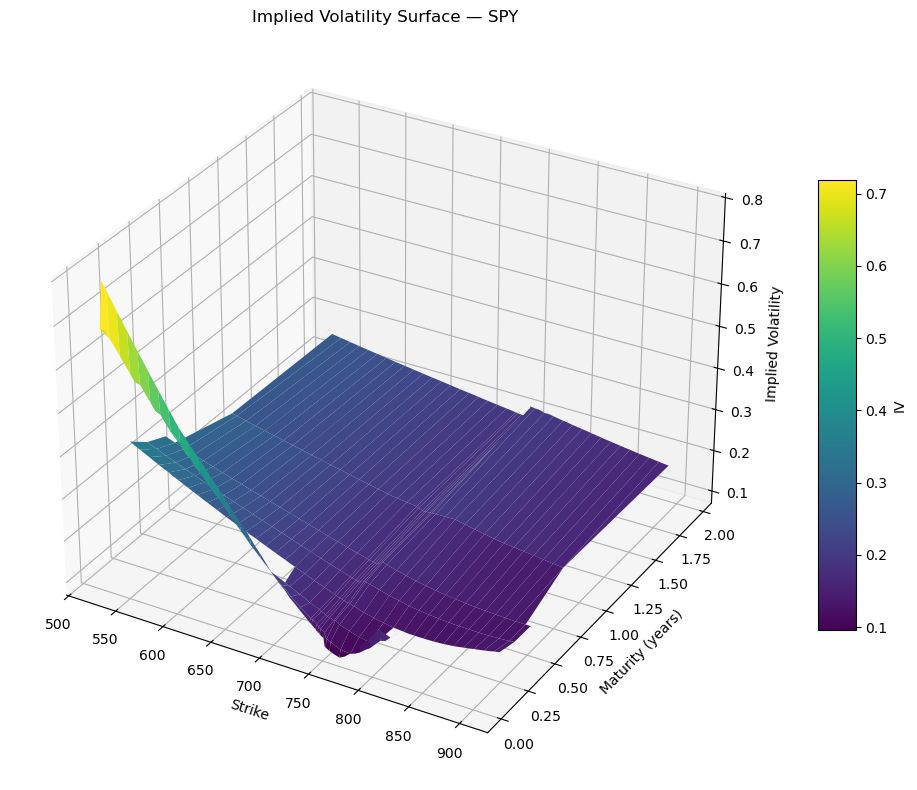

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D   # registra la proyección 3D

strikes = grid.columns.values      # eje X: los strikes
maturities = grid.index.values     # eje Y: los vencimientos (en años)
X, Y = np.meshgrid(strikes, maturities)   # rejilla 2D de coordenadas
Z = grid.values                    # las IV, ya en forma de matriz

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', antialiased=True)

ax.set_xlabel('Strike')
ax.set_ylabel('Maturity (years)')
ax.set_zlabel('Implied Volatility')
ax.set_title('Implied Volatility Surface — SPY')
fig.colorbar(surf, shrink=0.6, aspect=12, label='IV')
plt.tight_layout()
plt.show()

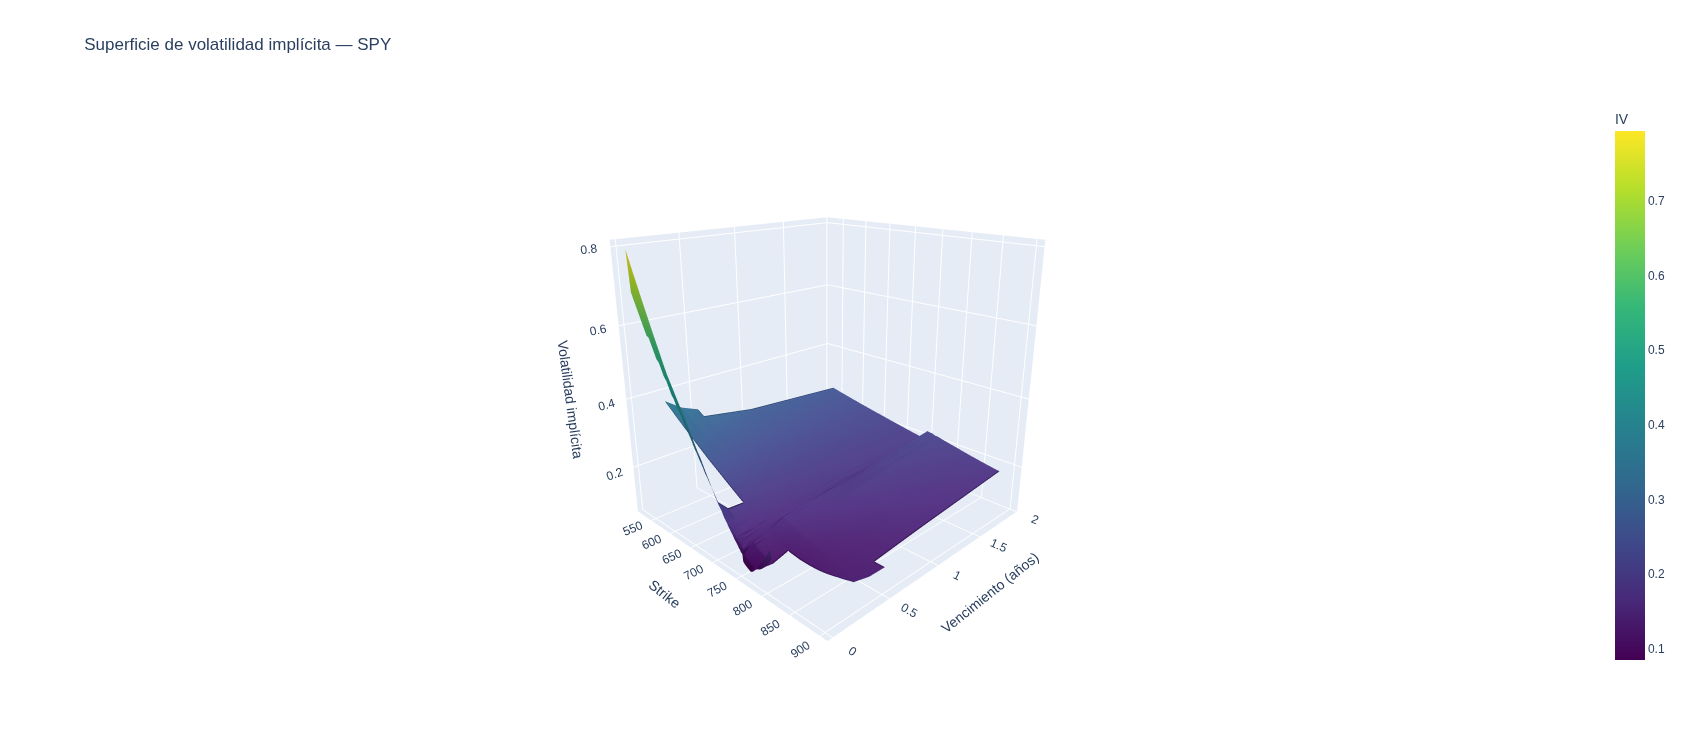

In [37]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Surface(
    x=grid.columns.values,      # strikes (eje X)
    y=grid.index.values,        # vencimientos en años (eje Y)
    z=grid.values,              # IV (eje Z, la altura)
    colorscale='Viridis',
    colorbar=dict(title='IV'),
    hovertemplate='Strike: %{x}<br>Vencimiento: %{y:.2f} años<br>IV: %{z:.4f}<extra></extra>'
)])

fig.update_layout(
    title='Superficie de volatilidad implícita — SPY',
    scene=dict(
        xaxis_title='Strike',
        yaxis_title='Vencimiento (años)',
        zaxis_title='Volatilidad implícita',
        camera=dict(eye=dict(x=1.6, y=-1.6, z=0.8))   # ángulo inicial que muestra bien el skew
    ),
    width=950,
    height=750
)

fig.show()